# Sodaku Game using RL methods ... 

In [1]:
import numpy as np

N = 5
nums = [1,2,3,4,5]

def is_valid(grid, r, c, val):
    # row check
    if val in grid[r]:
        return False
    # col check
    if val in grid[:, c]:
        return False
    return True

def find_empty(grid):
    for i in range(N):
        for j in range(N):
            if grid[i, j] == 0:
                return i, j
    return None

def solve_dp(grid):
    pos = find_empty(grid)
    if not pos:
        return True

    r, c = pos

    for v in nums:
        if is_valid(grid, r, c, v):
            grid[r, c] = v
            if solve_dp(grid):
                return True
            grid[r, c] = 0

    return False


grid = np.zeros((5,5), dtype=int)
solve_dp(grid)
print(grid)

[[1 2 3 4 5]
 [2 1 4 5 3]
 [3 4 5 1 2]
 [4 5 2 3 1]
 [5 3 1 2 4]]


# Environment.....

In [4]:
import numpy as np
import random
from collections import defaultdict

N = 5
nums = [1,2,3,4,5]

class SudokuEnv:
    def __init__(self):
        self.reset()

    def reset(self):
        self.grid = np.zeros((N, N), dtype=int)
        self.done = False
        return self.grid.copy()

    def is_valid(self, r, c, v):
        if v in self.grid[r]:
            return False
        if v in self.grid[:, c]:
            return False
        return True

    def available_actions(self):
        actions = []
        for i in range(N):
            for j in range(N):
                if self.grid[i, j] == 0:
                    for v in nums:
                        actions.append((i, j, v))
        return actions

    def step(self, action):
        if self.done:
            return self.grid.copy(), 0, True

        i, j, v = action

        if self.grid[i, j] != 0:
            return self.grid.copy(), -1.0, False

        if not self.is_valid(i, j, v):
            self.done = True
            return self.grid.copy(), -1.0, True

        self.grid[i, j] = v

        reward = 0.05

        if np.all(self.grid != 0):
            self.done = True
            reward += 10

        return self.grid.copy(), reward, self.done

# Dynamic programming 

In [5]:
def dp_solve(grid):
    def find_empty(g):
        for i in range(N):
            for j in range(N):
                if g[i, j] == 0:
                    return i, j
        return None

    def backtrack(g):
        pos = find_empty(g)
        if not pos:
            return True

        r, c = pos

        for v in nums:
            if v not in g[r] and v not in g[:, c]:
                g[r, c] = v
                if backtrack(g):
                    return True
                g[r, c] = 0

        return False

    g = grid.copy()
    success = backtrack(g)
    return g if success else None

# Monte carlo 

In [ ]:
Q_mc = defaultdict(float)
returns_mc = defaultdict(list)

gamma = 0.95

def mc_policy(env, eps=0.2):
    state = env.reset()
    episode = []

    while True:
        actions = env.available_actions()
        if random.random() < eps:
            action = random.choice(actions)
        else:
            q_vals = [Q_mc[(tuple(state.flatten()), a)] for a in actions]
            action = actions[np.argmax(q_vals)]

        next_state, reward, done = env.step(action)

        episode.append((state, action, reward))

        state = next_state
        if done:
            break

    G = 0
    visited = set()

    for t in reversed(range(len(episode))):
        s, a, r = episode[t]
        G = r + gamma * G

        key = (tuple(s.flatten()), a)

        if key not in visited:
            returns_mc[key].append(G)
            Q_mc[key] = np.mean(returns_mc[key])
            visited.add(key)

# Temporal difference 

In [6]:
V = defaultdict(float)
alpha = 0.1
gamma = 0.95

def td0_train(env, episodes=2000):
    for _ in range(episodes):
        state = env.reset()

        while True:
            s = tuple(state.flatten())
            actions = env.available_actions()

            action = random.choice(actions)
            next_state, reward, done = env.step(action)

            s2 = tuple(next_state.flatten())

            V[s] += alpha * (reward + gamma * V[s2] - V[s])

            state = next_state
            if done:
                break

# SARSA (On-policy TD Control)

In [7]:
Q_sarsa = defaultdict(float)
alpha = 0.1
gamma = 0.95
eps = 0.2

def choose_action(state, actions):
    if random.random() < eps:
        return random.choice(actions)
    q_vals = [Q_sarsa[(state, a)] for a in actions]
    return actions[np.argmax(q_vals)]

def sarsa_train(env, episodes=3000):
    for _ in range(episodes):
        state = tuple(env.reset().flatten())
        actions = env.available_actions()
        action = choose_action(state, actions)

        while True:
            next_state, reward, done = env.step(action)

            s2 = tuple(next_state.flatten())
            next_actions = env.available_actions()

            next_action = choose_action(s2, next_actions)

            Q_sarsa[(state, action)] += alpha * (
                reward + gamma * Q_sarsa[(s2, next_action)] - Q_sarsa[(state, action)]
            )

            state, action = s2, next_action

            if done:
                break

# Q-Learning (Off-policy Optimal Control)

In [ ]:
Q = defaultdict(float)
alpha = 0.1
gamma = 0.95
eps = 0.2

def q_learning(env, episodes=3000):
    for _ in range(episodes):
        state = tuple(env.reset().flatten())

        while True:
            actions = env.available_actions()

            if random.random() < eps:
                action = random.choice(actions)
            else:
                action = max(actions, key=lambda a: Q[(state, a)])

            next_state, reward, done = env.step(action)
            s2 = tuple(next_state.flatten())

            next_actions = env.available_actions()
            max_q_next = max([Q[(s2, a)] for a in next_actions], default=0)

            Q[(state, action)] += alpha * (
                reward + gamma * max_q_next - Q[(state, action)]
            )

            state = s2

            if done:
                break 

# Shared Training Logger

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def moving_average(x, w=50):
    return np.convolve(x, np.ones(w)/w, mode='valid')

# run dp 

In [9]:
def run_dp(env):
    grid = env.reset()
    solved = dp_solve(grid)
    return solved

# Evaluation Loop

In [10]:
def evaluate(env, policy_fn, episodes=200):
    rewards = []

    for ep in range(episodes):
        state = env.reset()
        total_reward = 0

        while True:
            action = policy_fn(env, state)
            state, reward, done = env.step(action)
            total_reward += reward

            if done:
                break

        rewards.append(total_reward)

    return rewards

# Monte Carlo Training

In [11]:
def train_mc(env, episodes=2000):
    Q = defaultdict(float)
    returns = defaultdict(list)
    rewards_log = []

    gamma = 0.95

    for ep in range(episodes):
        state = env.reset()
        episode = []
        total_reward = 0

        while True:
            actions = env.available_actions()
            action = random.choice(actions)

            next_state, reward, done = env.step(action)

            episode.append((state, action, reward))
            total_reward += reward

            state = next_state
            if done:
                break

        G = 0
        visited = set()

        for t in reversed(range(len(episode))):
            s, a, r = episode[t]
            G = r + gamma * G

            key = (tuple(s.flatten()), a)

            if key not in visited:
                returns[key].append(G)
                Q[key] = np.mean(returns[key])
                visited.add(key)

        rewards_log.append(total_reward)

    return Q, rewards_log

# TD

In [14]:
def train_td(env, episodes=2000):
    V = defaultdict(float)
    rewards_log = []

    alpha = 0.1
    gamma = 0.95

    for _ in range(episodes):
        state = env.reset()
        total_reward = 0

        while True:
            s = tuple(state.flatten())
            actions = env.available_actions()
            action = random.choice(actions)

            next_state, reward, done = env.step(action)
            s2 = tuple(next_state.flatten())

            V[s] += alpha * (reward + gamma * V[s2] - V[s])

            state = next_state
            total_reward += reward

            if done:
                break

        rewards_log.append(total_reward)

    return V, rewards_log

# Q-learning training 

In [12]:
def train_q(env, episodes=2000):
    Q = defaultdict(float)
    rewards_log = []

    alpha = 0.1
    gamma = 0.95
    eps = 0.2

    for ep in range(episodes):
        state = tuple(env.reset().flatten())
        total_reward = 0

        while True:
            actions = env.available_actions()

            if np.random.rand() < eps:
                action = random.choice(actions)
            else:
                action = max(actions, key=lambda a: Q[(state, a)])

            next_state, reward, done = env.step(action)
            s2 = tuple(next_state.flatten())

            next_actions = env.available_actions()
            max_q = max([Q[(s2, a)] for a in next_actions], default=0)

            Q[(state, action)] += alpha * (
                reward + gamma * max_q - Q[(state, action)]
            )

            state = s2
            total_reward += reward

            if done:
                break

        rewards_log.append(total_reward)

    return Q, rewards_log

# SARSA TRAINING

In [13]:
def train_sarsa(env, episodes=2000):
    Q = defaultdict(float)
    rewards_log = []

    alpha = 0.1
    gamma = 0.95
    eps = 0.2

    for ep in range(episodes):
        state = tuple(env.reset().flatten())
        actions = env.available_actions()
        action = random.choice(actions)

        total_reward = 0

        while True:
            next_state, reward, done = env.step(action)

            s2 = tuple(next_state.flatten())
            next_actions = env.available_actions()
            next_action = random.choice(next_actions)

            Q[(state, action)] += alpha * (
                reward + gamma * Q[(s2, next_action)] - Q[(state, action)]
            )

            state, action = s2, next_action
            total_reward += reward

            if done:
                break

        rewards_log.append(total_reward)

    return Q, rewards_log

# Train.....

In [15]:
env = SudokuEnv()

mc_Q, mc_rewards = train_mc(env)
td_V, td_rewards = train_td(env)
sarsa_Q, sarsa_rewards = train_sarsa(env)
q_Q, q_rewards = train_q(env)

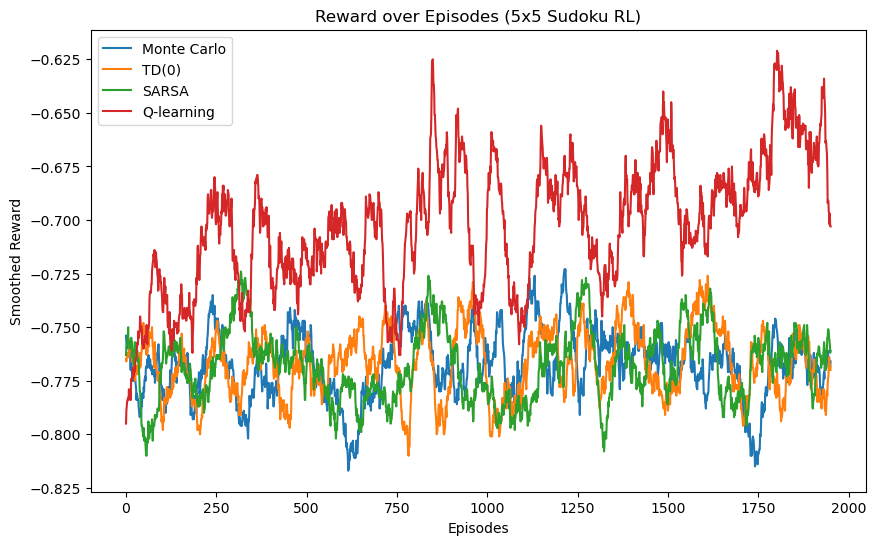

In [16]:
plt.figure(figsize=(10,6))

plt.plot(moving_average(mc_rewards), label="Monte Carlo")
plt.plot(moving_average(td_rewards), label="TD(0)")
plt.plot(moving_average(sarsa_rewards), label="SARSA")
plt.plot(moving_average(q_rewards), label="Q-learning")

plt.title("Reward over Episodes (5x5 Sudoku RL)")
plt.xlabel("Episodes")
plt.ylabel("Smoothed Reward")
plt.legend()
plt.show()

In [19]:
import numpy as np

def run_policy(env, Q=None, V=None, mode="q"):
    state = env.reset()
    grid = state.copy()

    while True:
        actions = env.available_actions()

        if len(actions) == 0:
            break

        # ---- Q-learning / SARSA ----
        if mode in ["q", "sarsa"]:
            s = tuple(state.flatten())
            action = max(actions, key=lambda a: Q[(s, a)])

        # ---- Monte Carlo ----
        elif mode == "mc":
            s = tuple(state.flatten())
            action = max(actions, key=lambda a: Q[(s, a)])

        # ---- TD (state-value only) ----
        elif mode == "td":
            # greedy rollout using best immediate reward heuristic
            action = actions[0]  # simplest fallback

        state, reward, done = env.step(action)
        grid = state.copy()

        if done:
            break

    return grid

In [20]:
env = SudokuEnv()
grid = env.reset()

solution_dp = dp_solve(grid)

print("\n=== DP Solution (Ground Truth) ===")
print(solution_dp)


=== DP Solution (Ground Truth) ===
[[1 2 3 4 5]
 [2 1 4 5 3]
 [3 4 5 1 2]
 [4 5 2 3 1]
 [5 3 1 2 4]]


In [21]:
env = SudokuEnv()
grid_mc = run_policy(env, Q=mc_Q, mode="mc")

print("\n=== Monte Carlo Learned Solution ===")
print(grid_mc)


=== Monte Carlo Learned Solution ===
[[0 0 0 1 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


In [24]:
env = SudokuEnv()
grid_td = run_policy(env, V=td_V, mode="td")

print("\n=== TD(0) Learned Solution (approx) ===")
print(grid_td)


=== TD(0) Learned Solution (approx) ===
[[1 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


In [22]:
env = SudokuEnv()
grid_sarsa = run_policy(env, Q=sarsa_Q, mode="sarsa")

print("\n=== SARSA Learned Solution ===")
print(grid_sarsa)


=== SARSA Learned Solution ===
[[3 0 0 1 0]
 [5 0 0 0 0]
 [0 3 0 0 0]
 [0 0 0 4 0]
 [0 0 0 0 0]]


In [23]:
env = SudokuEnv()
grid_q = run_policy(env, Q=q_Q, mode="q")

print("\n=== Q-learning Learned Solution ===")
print(grid_q)


=== Q-learning Learned Solution ===
[[1 2 3 4 5]
 [3 5 2 1 4]
 [2 4 1 3 0]
 [4 0 0 2 1]
 [5 0 4 0 3]]
